### Plot Intensity Distributions
Andrew Gettelman, July 2025

Code to plot intensity distributions pre-calculated.

Two types of files:
1. Juan Henao files (`/glade/derecho/scratch/jhenao/*_intensity_v0.nc`): density
2. Andrew G. files: using Juan's routine : just counts (`/glade/work/andrew/hackathon/intensity_*_z8_v0.nc`)

In [98]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import uxarray as ux
import intake
import numpy as np

import pandas as pd

import healpix as hp
import holoviews as hv

import easygems.healpix as egh
import easygems.remap as egr

import easygems.healpix as eghp

import cmocean
import geoviews.feature as gf
import pickle

### Load some regions

In [99]:
dir_ken = '/glade/derecho/scratch/khirata/'
dir_juan = '/glade/derecho/scratch/jhenao/'
# open precalculated regions
with open(dir_juan + "region_trop_midlat_healpix_cells_zoom8.pkl", "rb") as f:
    region_cells_dic = pickle.load(f)

In [100]:
region_cells_dic

{'midlatitudes_land': array([ 13655,  13659,  13660, ..., 772776, 772777, 772778],
       shape=(74851,)),
 'tropical_land': array([    42,     43,     46, ..., 786378, 786400, 786402],
       shape=(96421,)),
 'midlatitudes_ocean': array([ 25278,  25279,  25306, ..., 772516, 772517, 772518],
       shape=(202842,)),
 'tropical_ocean': array([     0,      1,      2, ..., 786429, 786430, 786431],
       shape=(283001,))}

In [101]:
def get_regional_cells(data, region_cells_dict):
    """
    get regional values using the previously saved
    cells for each box, averaged over all months 
    """
    return {
        region: data.isel(cell=cells).mean(dim='cell')
        for region, cells in region_cells_dict.items()
    }

def get_regional_nface(data, region_cells_dict):
    """
    get regional values using the previously saved
    cells for each box, averaged over all months 
    """
    return {
        region: data.isel(n_face=cells).mean(dim='n_face')
        for region, cells in region_cells_dict.items()
    }


In [102]:
def get_combined_regional_cells(data, region_cells_dict):
    regional_means = [
        data.isel(cell=cells).mean(dim='cell').expand_dims(region=[region])
        for region, cells in region_cells_dict.items()
    ]
    return xr.concat(regional_means, dim='region')

def get_combined_regional_nface(data, region_cells_dict):
    regional_means = [
        data.isel(n_face=cells).mean(dim='n_face').expand_dims(region=[region])
        for region, cells in region_cells_dict.items()
    ]
    return xr.concat(regional_means, dim='region')

### Paths 

In [103]:
apth='/glade/work/andrew/hackathon/'
jpth='/glade/derecho/scratch/jhenao/'

In [104]:
#Juan Bins? Did he use mine?

# Bin centers
binctr = [0.1, 0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200, 300, 500, 600, 800, 1000]

# Create bin edges list
bin_edges = [0.]  # First edge is 0 as specified

# Calculate intermediate edges as geometric means between bin centers
for i in range(len(binctr)-1):
    # Geometric mean: sqrt(a * b)
    edge = np.sqrt(binctr[i] * binctr[i+1])
    bin_edges.append(edge)

# Add the final edge
bin_edges.append(2000.)  # Last edge is 2000 as specified

#print(bin_edges)

### Test read and compare: 1 model

In [113]:
mname='ew'

jfn=jpth+mname+'_intensity_v0.nc'
afn=apth+'intensity_'+mname+'_z8_v3.nc'

dsa=xr.open_dataset(afn)
dsj=xr.open_dataset(jfn)
dsj=dsj.assign_coords(bin=binctr)

In [114]:
dsj

<xarray.Dataset> Size: 1GB
Dimensions:  (month: 12, cell: 786432, bin: 16)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * bin      (bin) float64 128B 0.1 0.2 0.5 1.0 2.0 ... 500.0 600.0 800.0 1e+03
Dimensions without coordinates: cell
Data variables:
    pr       (month, cell, bin) float64 1GB ...

In [115]:
# Returns dataset...
regional_umj = get_combined_regional_cells(dsj, region_cells_dic)
regional_umj

<xarray.Dataset> Size: 6kB
Dimensions:  (region: 4, month: 12, bin: 16)
Coordinates:
  * region   (region) object 32B 'midlatitudes_land' ... 'tropical_ocean'
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * bin      (bin) float64 128B 0.1 0.2 0.5 1.0 2.0 ... 500.0 600.0 800.0 1e+03
Data variables:
    pr       (region, month, bin) float64 6kB 0.668 0.0755 ... 0.0001426

### Plot

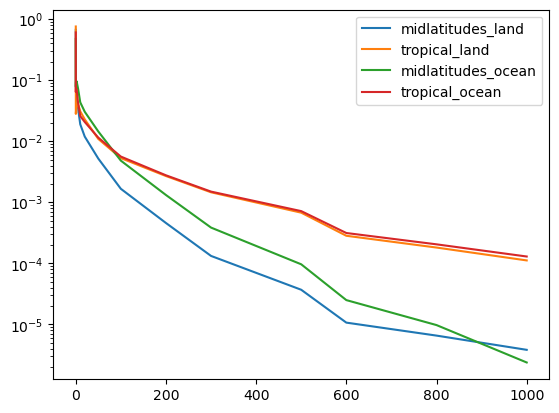

In [116]:
m=1

for rname in regional_umj.region.values:
    plt.plot(regional_umj.bin,regional_umj.pr.sel(region=rname,month=m),label=rname)
plt.yscale('log')
plt.legend()

In [117]:
### For Andrew Files, make frequency first and average....
# Divide by total number in all bins each month....

counts=dsa.sum(dim='bin')
safe_totals = counts.where(counts != 0)
density = dsa / counts

In [118]:
density

<xarray.Dataset> Size: 1GB
Dimensions:  (month: 12, bin: 16, n_face: 786432)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * bin      (bin) float64 128B 0.1 0.2 0.5 1.0 2.0 ... 500.0 600.0 800.0 1e+03
Dimensions without coordinates: n_face
Data variables:
    pr       (month, n_face, bin) float64 1GB 0.7187 0.04418 0.05377 ... 0.0 0.0

In [119]:
regional_uma = get_combined_regional_nface(density, region_cells_dic)

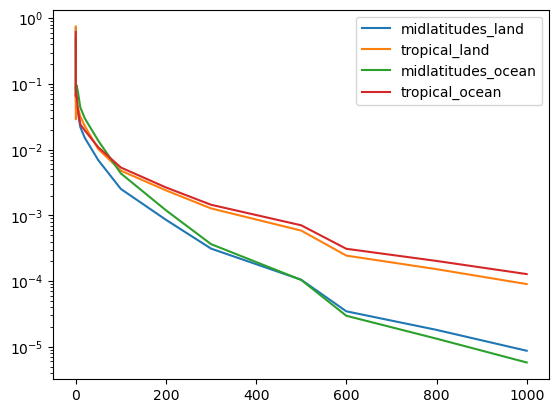

In [120]:
m=1

for rname in regional_uma.region.values:
    plt.plot(regional_uma.bin,regional_uma.pr.sel(region=rname,month=m),label=rname)
plt.yscale('log')
plt.legend()